# Outline Python script for the MS3.08 Introduction to Computer Controlled Experiments
### Version 1.1 - Updated 7 October 2025 by BFS
Nick Brooks

# 0. Instructions

This notebook provides an outline for developing a program that will allow you to investigate the conductivity of simple electronic components. It communicate with an Arduino that is configured to provide as a voltage source, as well as read the potential across the test component and current flowing through it. A full description of the experiment and the way that you communicate with the Arduino is available on Blackboard. 
Before you begin, you will need to install a module that lets Python communicate through a serial connection with other pieces of equipment. You only need to do this once to get everything set up.

Before you start, you need to install a Python module that allows you to work with serial connections to your computer, you only need to do this once and it will stay installed in your Python distribution.

Run the cell below and wait for the module to download and install.

In [66]:
pip install pyserial

Note: you may need to restart the kernel to use updated packages.


If you receive a 'syntax error' when running to command above, please run the same command in a terminal window. If you are using Windows, you can launch a terminal window by typing CMD into the main Windows search bar (this is usually towards the left of the main toolbar at the bottom of your screen) and running the CMD program. If you are using MacOS or Linux, you can open the 'Terminal' program from your application launcher.

Next you need to point the program that you'll be writing towards the libraries that it will need to run. The libraries that you need are the 'serial' library that contains the commands for serial communicaiton, some parts of serial tools so you can find the name of the port that your instrument is connected to, 'time' for allowing your program to wiat and the standard tools that you have used in the past for data manipulation, curve plotting and fitting.<br>
Run the cell below to import the appropriate libraries.

In [25]:
import serial
import serial.tools.list_ports
import time
%pylab inline
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import csv
from datetime import datetime

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


So that you can tell your program where to send and receive information, you need to find the name of the port that you have connected your instrument to. The port is a virtual serial port that runs over the USB connection (effectively the serial commands are send over USB and then decoded in the instrument).<br>
Start by making sure that your Arduino is <b>disconnected</b> from your computer, run the cell below and make a note of the port names that show up (there may be no ports shown at this point). Next <b>connect</b> your instrument to a USB port on your computer, wait for a moment to check that any required drivers are installed (on Windows you may see a message saying that your device is being prepared and then one to say that it is ready for use), and then run the cell below again to get an updated list of the available serial ports. The name of the extra port that shows up with your Arduino connected is the one that you should use in the subsequent code.
Note that the port naming scheme is different depending on your opperating systems:<br>
<b>Windows.</b> If you are using Windows, your Arduino will show up on a port named 'COM' and then a number (e.g. COM7).<br>
<b>MacOS or Linux.</b> If you are using MacOS or Linux, your Arduino port will be named similar to '/dev/cu.usbmodem' and then a number.

In [60]:
ports = serial.tools.list_ports.comports()

for p in ports:
    print(p.device)
print (len(ports), 'ports found')

/dev/cu.debug-console
/dev/cu.Bluetooth-Incoming-Port
/dev/cu.usbmodem2101
3 ports found


To open the serial connection between your computer and Arduino, you need to specify the parameters that the Arduino uses to communicate. You will need to specify the port name, a baud rate (the number of bits per second) of 9600, and a timeout time of 2 seconds.<br>
You can use the following code outline to open a serial conection that we're going to name 'ser':<br>
```python
ser = serial.Serial('port name', baudrate=x, timeout=x)```

For example (note that you will need to change the port name to match the one found above):

```python
ser = serial.Serial('/dev/cu.usbmodem144301', baudrate=9600, timeout=2)```

In [61]:
ser = serial.Serial('/dev/cu.usbmodem2101', baudrate=9600, timeout=2)

When the serial connection is opened, the Arduino will reset and it will send three lines of information back to the computer. You can read each line into a variable called ```b``` using the code:
```python
b = ser.readline()```

The text is read in as a list of 8-bit characters which you can print out directly, but it may be useful to convert it to a string. You can use the following code to covert the chracter list to a string named ```readstring```:

```python
readstring = b.decode("utf-8")```

Finally, you can print each line as it is read using:

```python
print(readstring)```

You may find it useful to run these commands in a ```for``` loop that repeats 3 times rather than just repeating then 3 times explicitly.

In [62]:
for i in range(3):
    b = ser.readline()
    readstring = b.decode("utf-8")
    readstring
    print(readstring)

Next, you should try to send some commands to the Arduino and then read back the response.<br>
You can send a command using the code: ```ser.write(bytestowrite)```, but remember from above that the information is sent and received as a list of 8-bit characters which is subtally different from a python string. To get a command ready to send, you need to define a string to send, for example using:
```python
writestring = '<S0>'```
Then this string needs to be encoded as a list of 8-bit ASCII characters using:
```python
bytestowrite = writestring.encode()```
After the command has been sent, the Arduino will receive it, process is and respond with one line which you should read as you did in the cell above (but remember there will only be one line now rather than three).

In [63]:
writestring = '<S0.00>'
bytestowrite = writestring.encode()
ser.write(bytestowrite)

7

In [64]:
response = ser.readline()
print(response.decode('utf-8'))

S 0.000



Now try to set up a loop that sets the applied voltage in small steps between 0 and 5 volts and at each step reads the current running through the LED, and the voltage across it. You will need to store each reading in a list so you can plot them later. You should think about if it is appropriate to insert short delays in the program (for instance to allow the set voltage to stabilise before reading your data), you can do this using the command:
```python
time.sleep(0.1)```
Where the number in brackets is the number of seconds to wait (100 ms in the example above).

Plot out your data and think about how you could extend the experiment, for example, can you measure multiple LEDs and compare their response, how does the response of an LED compare to a standard resistor?

When you are finished, you should close the serial connection. Only one program at a time can send information to a particular serial port, so by closing the connection, you free it up so that other programs could communicate with your instrument. Make sure you open the connection again when you want to start working again.<br>
You can close the connection using the following command:
```python
ser.close()```


# 1. Test Variables

## 0. Start and End Voltage

As shown in various I-V plots below, the modification of start and end voltage is deemed unnecessary. This is due to:
1. The resistance of LEDs before turn-on voltage can be effectively seen as *infinite*, so start voltages do not affect the overall performance of LEDs;
2. Across different LEDs, the currents at ~2.5 V are already quite high and seems are automatically cut off by the microcontroller, so there is no point changing this value either 

## 1. Delay Time
In this section, we tested out the **optimal delay time** between each reading. We chose green LED as it has a modest bandgap. We tested 0.01 s, 0.05 s, 0.1 s, 0.15 s, 0.2 s, 0.3 s and found that 0.1 s is the optimal balance between efficicency and accuracy.

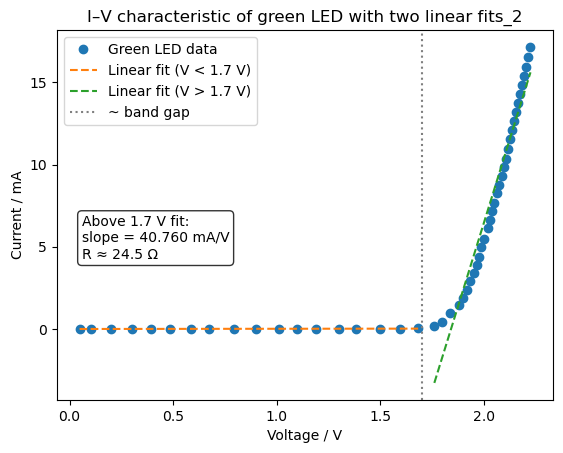

In [46]:
#Green LED, delay 0.01
import time

# Lists to store data
green_voltages_2 = []
green_currents_2 = []

# Define sweep parameters
v_start = 0.0
v_stop = 5.0
v_step = 0.1

v = v_start
while v <= v_stop:
    # 1. Set voltage
    cmd = f'<S{v:.2f}>'
    ser.write(cmd.encode())
    ser.readline()  # read acknowledgement

    # 2. Allow voltage to stabilise
    time.sleep(0.01)

    # 3. Read LED voltage (A1)
    ser.write(b'<V2>')
    v_led = ser.readline().decode().strip()
    V = float(v_led.split()[1])

    # 4. Read current
    ser.write(b'<I1>')
    i_led = ser.readline().decode().strip()
    I = float(i_led.split()[1])

    # 5. Store data
    green_voltages_2.append(V)
    green_currents_2.append(I)

    v += v_step
    
import numpy as np

V = np.array(green_voltages_2)
I = np.array(green_currents_2)

V_split = 1.7

mask_low = V < V_split
mask_high = V > V_split

V_low = V[mask_low]
I_low = I[mask_low]

V_high = V[mask_high]
I_high = I[mask_high]

m_low, c_low = np.polyfit(V_low, I_low, 1)
m_high, c_high = np.polyfit(V_high, I_high, 1)

plt.figure()

plt.plot(V, I, 'o', label='Green LED data')

V_fit_low = np.linspace(V_low.min(), V_low.max(), 100)
I_fit_low = m_low * V_fit_low + c_low

V_fit_high = np.linspace(V_high.min(), V_high.max(), 100)
I_fit_high = m_high * V_fit_high + c_high

R_high = 1000 / m_high  # ohms (since m_high is in mA/V)
textstr = (
    f"Above 1.7 V fit:\n"
    f"slope = {m_high:.3f} mA/V\n"
    f"R ≈ {R_high:.1f} Ω"
)

plt.text(
    0.05, 0.5, textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.plot(V_fit_low, I_fit_low, '--', label='Linear fit (V < 1.7 V)')
plt.plot(V_fit_high, I_fit_high, '--', label='Linear fit (V > 1.7 V)')

plt.axvline(V_split, color='grey', linestyle=':', label='~ band gap')

plt.xlabel('Voltage / V')
plt.ylabel('Current / mA')
plt.title('I–V characteristic of green LED with two linear fits_2')
plt.legend()
plt.show()

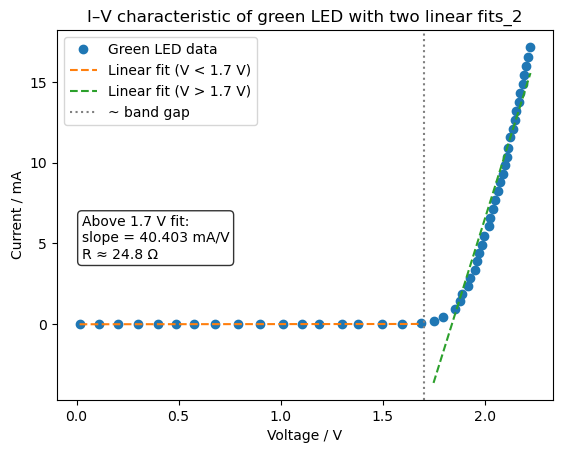

In [43]:
#Green LED, delay 0.05
import time

# Lists to store data
green_voltages_2 = []
green_currents_2 = []

# Define sweep parameters
v_start = 0.0
v_stop = 5.0
v_step = 0.1

v = v_start
while v <= v_stop:
    # 1. Set voltage
    cmd = f'<S{v:.2f}>'
    ser.write(cmd.encode())
    ser.readline()  # read acknowledgement

    # 2. Allow voltage to stabilise
    time.sleep(0.05)

    # 3. Read LED voltage (A1)
    ser.write(b'<V2>')
    v_led = ser.readline().decode().strip()
    V = float(v_led.split()[1])

    # 4. Read current
    ser.write(b'<I1>')
    i_led = ser.readline().decode().strip()
    I = float(i_led.split()[1])

    # 5. Store data
    green_voltages_2.append(V)
    green_currents_2.append(I)

    v += v_step
    
import numpy as np

V = np.array(green_voltages_2)
I = np.array(green_currents_2)

V_split = 1.7

mask_low = V < V_split
mask_high = V > V_split

V_low = V[mask_low]
I_low = I[mask_low]

V_high = V[mask_high]
I_high = I[mask_high]

m_low, c_low = np.polyfit(V_low, I_low, 1)
m_high, c_high = np.polyfit(V_high, I_high, 1)

plt.figure()

plt.plot(V, I, 'o', label='Green LED data')

V_fit_low = np.linspace(V_low.min(), V_low.max(), 100)
I_fit_low = m_low * V_fit_low + c_low

V_fit_high = np.linspace(V_high.min(), V_high.max(), 100)
I_fit_high = m_high * V_fit_high + c_high

R_high = 1000 / m_high  # ohms (since m_high is in mA/V)
textstr = (
    f"Above 1.7 V fit:\n"
    f"slope = {m_high:.3f} mA/V\n"
    f"R ≈ {R_high:.1f} Ω"
)

plt.text(
    0.05, 0.5, textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.plot(V_fit_low, I_fit_low, '--', label='Linear fit (V < 1.7 V)')
plt.plot(V_fit_high, I_fit_high, '--', label='Linear fit (V > 1.7 V)')

plt.axvline(V_split, color='grey', linestyle=':', label='~ band gap')

plt.xlabel('Voltage / V')
plt.ylabel('Current / mA')
plt.title('I–V characteristic of green LED with two linear fits_2')
plt.legend()
plt.show()

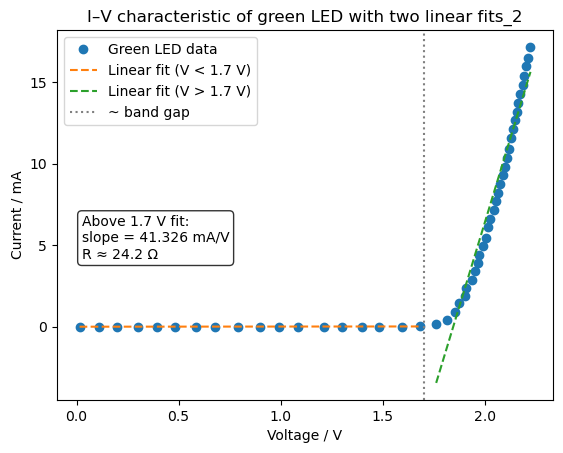

In [48]:
#Green LED, delay 0.075
import time

# Lists to store data
green_voltages_2 = []
green_currents_2 = []

# Define sweep parameters
v_start = 0.0
v_stop = 5.0
v_step = 0.1

v = v_start
while v <= v_stop:
    # 1. Set voltage
    cmd = f'<S{v:.2f}>'
    ser.write(cmd.encode())
    ser.readline()  # read acknowledgement

    # 2. Allow voltage to stabilise
    time.sleep(0.075)

    # 3. Read LED voltage (A1)
    ser.write(b'<V2>')
    v_led = ser.readline().decode().strip()
    V = float(v_led.split()[1])

    # 4. Read current
    ser.write(b'<I1>')
    i_led = ser.readline().decode().strip()
    I = float(i_led.split()[1])

    # 5. Store data
    green_voltages_2.append(V)
    green_currents_2.append(I)

    v += v_step
    
import numpy as np

V = np.array(green_voltages_2)
I = np.array(green_currents_2)

V_split = 1.7

mask_low = V < V_split
mask_high = V > V_split

V_low = V[mask_low]
I_low = I[mask_low]

V_high = V[mask_high]
I_high = I[mask_high]

m_low, c_low = np.polyfit(V_low, I_low, 1)
m_high, c_high = np.polyfit(V_high, I_high, 1)

plt.figure()

plt.plot(V, I, 'o', label='Green LED data')

V_fit_low = np.linspace(V_low.min(), V_low.max(), 100)
I_fit_low = m_low * V_fit_low + c_low

V_fit_high = np.linspace(V_high.min(), V_high.max(), 100)
I_fit_high = m_high * V_fit_high + c_high

R_high = 1000 / m_high  # ohms (since m_high is in mA/V)
textstr = (
    f"Above 1.7 V fit:\n"
    f"slope = {m_high:.3f} mA/V\n"
    f"R ≈ {R_high:.1f} Ω"
)

plt.text(
    0.05, 0.5, textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.plot(V_fit_low, I_fit_low, '--', label='Linear fit (V < 1.7 V)')
plt.plot(V_fit_high, I_fit_high, '--', label='Linear fit (V > 1.7 V)')

plt.axvline(V_split, color='grey', linestyle=':', label='~ band gap')

plt.xlabel('Voltage / V')
plt.ylabel('Current / mA')
plt.title('I–V characteristic of green LED with two linear fits_2')
plt.legend()
plt.show()

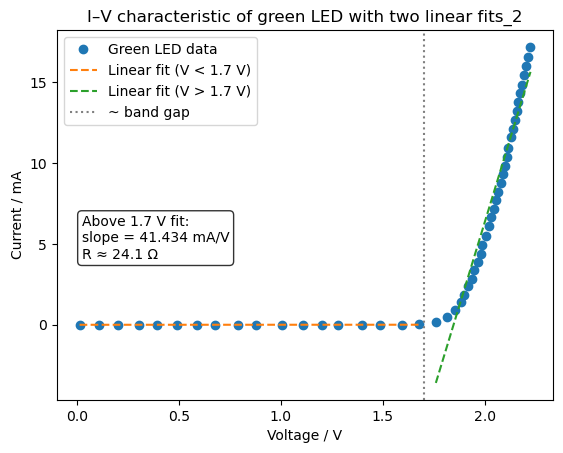

In [63]:
#Green LED, delay 0.15
import time

# Lists to store data
green_voltages_2 = []
green_currents_2 = []

# Define sweep parameters
v_start = 0.0
v_stop = 5.0
v_step = 0.1

v = v_start
while v <= v_stop:
    # 1. Set voltage
    cmd = f'<S{v:.2f}>'
    ser.write(cmd.encode())
    ser.readline()  # read acknowledgement

    # 2. Allow voltage to stabilise
    time.sleep(0.15)

    # 3. Read LED voltage (A1)
    ser.write(b'<V2>')
    v_led = ser.readline().decode().strip()
    V = float(v_led.split()[1])

    # 4. Read current
    ser.write(b'<I1>')
    i_led = ser.readline().decode().strip()
    I = float(i_led.split()[1])

    # 5. Store data
    green_voltages_2.append(V)
    green_currents_2.append(I)

    v += v_step
    
import numpy as np

V = np.array(green_voltages_2)
I = np.array(green_currents_2)

V_split = 1.7

mask_low = V < V_split
mask_high = V > V_split

V_low = V[mask_low]
I_low = I[mask_low]

V_high = V[mask_high]
I_high = I[mask_high]

m_low, c_low = np.polyfit(V_low, I_low, 1)
m_high, c_high = np.polyfit(V_high, I_high, 1)

plt.figure()

plt.plot(V, I, 'o', label='Green LED data')

V_fit_low = np.linspace(V_low.min(), V_low.max(), 100)
I_fit_low = m_low * V_fit_low + c_low

V_fit_high = np.linspace(V_high.min(), V_high.max(), 100)
I_fit_high = m_high * V_fit_high + c_high

R_high = 1000 / m_high  # ohms (since m_high is in mA/V)
textstr = (
    f"Above 1.7 V fit:\n"
    f"slope = {m_high:.3f} mA/V\n"
    f"R ≈ {R_high:.1f} Ω"
)

plt.text(
    0.05, 0.5, textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.plot(V_fit_low, I_fit_low, '--', label='Linear fit (V < 1.7 V)')
plt.plot(V_fit_high, I_fit_high, '--', label='Linear fit (V > 1.7 V)')

plt.axvline(V_split, color='grey', linestyle=':', label='~ band gap')

plt.xlabel('Voltage / V')
plt.ylabel('Current / mA')
plt.title('I–V characteristic of green LED with two linear fits_2')
plt.legend()
plt.show()

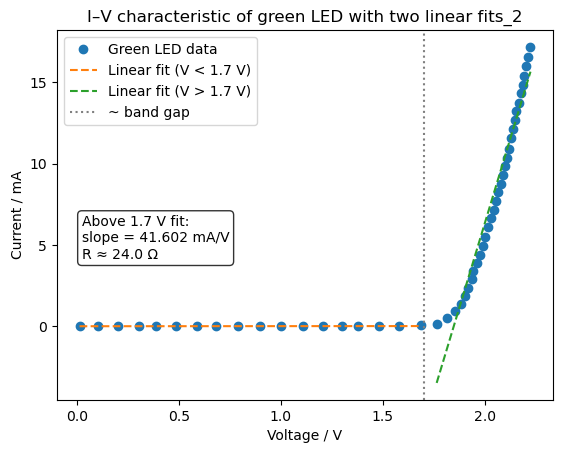

In [44]:
#Green LED, delay 0.2
import time

# Lists to store data
green_voltages_2 = []
green_currents_2 = []

# Define sweep parameters
v_start = 0.0
v_stop = 5.0
v_step = 0.1

v = v_start
while v <= v_stop:
    # 1. Set voltage
    cmd = f'<S{v:.2f}>'
    ser.write(cmd.encode())
    ser.readline()  # read acknowledgement

    # 2. Allow voltage to stabilise
    time.sleep(0.2)

    # 3. Read LED voltage (A1)
    ser.write(b'<V2>')
    v_led = ser.readline().decode().strip()
    V = float(v_led.split()[1])

    # 4. Read current
    ser.write(b'<I1>')
    i_led = ser.readline().decode().strip()
    I = float(i_led.split()[1])

    # 5. Store data
    green_voltages_2.append(V)
    green_currents_2.append(I)

    v += v_step
    
import numpy as np

V = np.array(green_voltages_2)
I = np.array(green_currents_2)

V_split = 1.7

mask_low = V < V_split
mask_high = V > V_split

V_low = V[mask_low]
I_low = I[mask_low]

V_high = V[mask_high]
I_high = I[mask_high]

m_low, c_low = np.polyfit(V_low, I_low, 1)
m_high, c_high = np.polyfit(V_high, I_high, 1)

plt.figure()

plt.plot(V, I, 'o', label='Green LED data')

V_fit_low = np.linspace(V_low.min(), V_low.max(), 100)
I_fit_low = m_low * V_fit_low + c_low

V_fit_high = np.linspace(V_high.min(), V_high.max(), 100)
I_fit_high = m_high * V_fit_high + c_high

R_high = 1000 / m_high  # ohms (since m_high is in mA/V)
textstr = (
    f"Above 1.7 V fit:\n"
    f"slope = {m_high:.3f} mA/V\n"
    f"R ≈ {R_high:.1f} Ω"
)

plt.text(
    0.05, 0.5, textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.plot(V_fit_low, I_fit_low, '--', label='Linear fit (V < 1.7 V)')
plt.plot(V_fit_high, I_fit_high, '--', label='Linear fit (V > 1.7 V)')

plt.axvline(V_split, color='grey', linestyle=':', label='~ band gap')

plt.xlabel('Voltage / V')
plt.ylabel('Current / mA')
plt.title('I–V characteristic of green LED with two linear fits_2')
plt.legend()
plt.show()

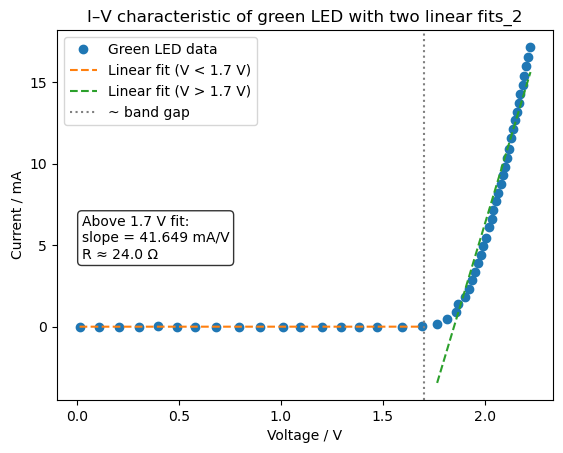

In [47]:
#Green LED, delay 0.3
import time

# Lists to store data
green_voltages_2 = []
green_currents_2 = []

# Define sweep parameters
v_start = 0.0
v_stop = 5.0
v_step = 0.1

v = v_start
while v <= v_stop:
    # 1. Set voltage
    cmd = f'<S{v:.2f}>'
    ser.write(cmd.encode())
    ser.readline()  # read acknowledgement

    # 2. Allow voltage to stabilise
    time.sleep(0.3)

    # 3. Read LED voltage (A1)
    ser.write(b'<V2>')
    v_led = ser.readline().decode().strip()
    V = float(v_led.split()[1])

    # 4. Read current
    ser.write(b'<I1>')
    i_led = ser.readline().decode().strip()
    I = float(i_led.split()[1])

    # 5. Store data
    green_voltages_2.append(V)
    green_currents_2.append(I)

    v += v_step
    
import numpy as np

V = np.array(green_voltages_2)
I = np.array(green_currents_2)

V_split = 1.7

mask_low = V < V_split
mask_high = V > V_split

V_low = V[mask_low]
I_low = I[mask_low]

V_high = V[mask_high]
I_high = I[mask_high]

m_low, c_low = np.polyfit(V_low, I_low, 1)
m_high, c_high = np.polyfit(V_high, I_high, 1)

plt.figure()

plt.plot(V, I, 'o', label='Green LED data')

V_fit_low = np.linspace(V_low.min(), V_low.max(), 100)
I_fit_low = m_low * V_fit_low + c_low

V_fit_high = np.linspace(V_high.min(), V_high.max(), 100)
I_fit_high = m_high * V_fit_high + c_high

R_high = 1000 / m_high  # ohms (since m_high is in mA/V)
textstr = (
    f"Above 1.7 V fit:\n"
    f"slope = {m_high:.3f} mA/V\n"
    f"R ≈ {R_high:.1f} Ω"
)

plt.text(
    0.05, 0.5, textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.plot(V_fit_low, I_fit_low, '--', label='Linear fit (V < 1.7 V)')
plt.plot(V_fit_high, I_fit_high, '--', label='Linear fit (V > 1.7 V)')

plt.axvline(V_split, color='grey', linestyle=':', label='~ band gap')

plt.xlabel('Voltage / V')
plt.ylabel('Current / mA')
plt.title('I–V characteristic of green LED with two linear fits_2')
plt.legend()
plt.show()

## 2. Step Voltage

In this section, we tested out the **optimal step voltage** between each reading. We chose green LED as it has a modest bandgap. We tested 0.05 V, 0.1 V, 0.2 V, 0.5 V and 1 V and found that 0.1 V is the optimal balance between efficicency and accuracy. 
We have used an input structure to plot and save the figure directly, and therefore only one figure is shown in the Jupyter Notebook.

In [38]:
import time
import numpy as np
import matplotlib.pyplot as plt

def run_led_iv_sweep(
    ser,
    v_start=0.0,
    v_stop=5.0,
    v_step=0.01,
    V_split=1.7,
    led_label="Green LED"
):
    """
    Run I–V sweep for an LED and perform two linear fits.

    Parameters
    ----------
    ser : serial.Serial
        Open serial connection
    v_start : float
        Start voltage (V)
    v_stop : float
        Stop voltage (V)
    v_step : float
        Step voltage (V)
    V_split : float
        Voltage separating low and high regions (V)
    led_label : str
        Label for plots
    """

    voltages = []
    currents = []

    v = v_start
    while v <= v_stop:
        # 1. Set voltage
        cmd = f'<S{v:.2f}>'
        ser.write(cmd.encode())
        ser.readline()  # acknowledgement

        # 2. Stabilise
        time.sleep(0.3)

        # 3. Read LED voltage (A1)
        ser.write(b'<V2>')
        v_led = ser.readline().decode().strip()
        V = float(v_led.split()[1])

        # 4. Read current
        ser.write(b'<I1>')
        i_led = ser.readline().decode().strip()
        I = float(i_led.split()[1])

        # 5. Store
        voltages.append(V)
        currents.append(I)

        v += v_step

    # Convert to arrays
    V = np.array(voltages)
    I = np.array(currents)

    # Split regions
    mask_low = V < V_split
    mask_high = V > V_split

    V_low, I_low = V[mask_low], I[mask_low]
    V_high, I_high = V[mask_high], I[mask_high]

    # Linear fits
    m_low, c_low = np.polyfit(V_low, I_low, 1)
    m_high, c_high = np.polyfit(V_high, I_high, 1)

    # Resistance estimate (mA/V → A/V)
    R_high = 1000 / m_high

    # Plot
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    plt.plot(V, I, 'o', label=f'{led_label} data')

    V_fit_low = np.linspace(V_low.min(), V_low.max(), 100)
    V_fit_high = np.linspace(V_high.min(), V_high.max(), 100)

    plt.plot(V_fit_low, m_low * V_fit_low + c_low, '--',
             label='Linear fit (V < split)', linewidth=2.5)
    plt.plot(V_fit_high, m_high * V_fit_high + c_high, '--',
             label='Linear fit (V > split)', linewidth=2.5)

    plt.axvline(V_split, color='grey', linestyle=':', label='~ band gap', linewidth=2.5)

    textstr = (
        f"Above {V_split:.2f} V fit:\n"
        f"slope = {m_high:.3f} mA/V\n"
        f"R ≈ {R_high:.1f} Ω"
    )

    plt.text(
        0.02, 0.75, textstr,
        transform=plt.gca().transAxes,
        fontsize=12, fontweight='bold',
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    
    plt.title(f'I–V plot of {led_label}, step voltage = 0.05 V', fontsize=20, fontweight="bold")
    plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
    plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
    plt.xticks(fontsize=14, fontweight='bold')
    plt.yticks(fontsize=14, fontweight='bold')
    plt.legend(prop={'size': 10, 'weight': 'bold'})
    plt.savefig("I-V plot, green LED, step voltage = 0.05 V.png", dpi=600)
    plt.tight_layout()
    plt.show()

    return V, I, m_low, m_high, R_high


Enter step voltage (V):  0.05


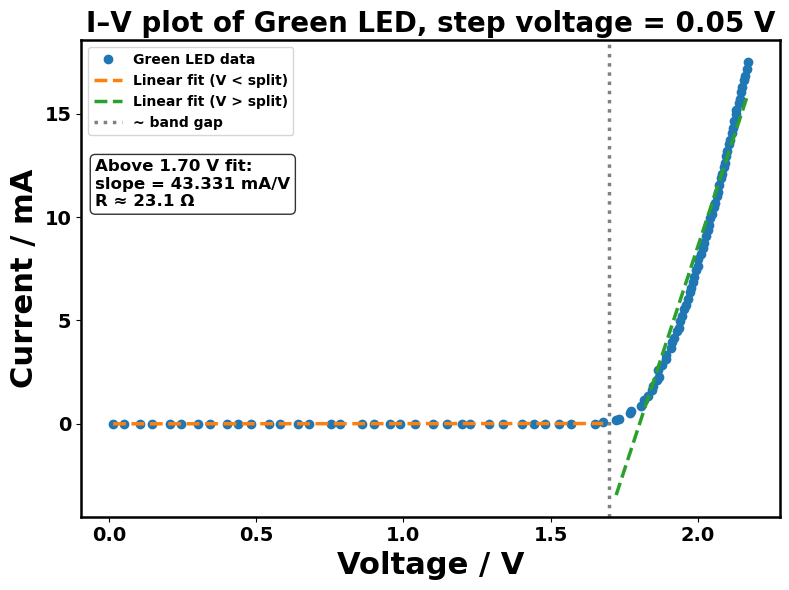

In [39]:
# ST= 0.5
step = float(input("Enter step voltage (V): "))
V, I, m_low, m_high, R = run_led_iv_sweep(
    ser,
    v_step=step,
    V_split=1.7,
    led_label="Green LED"
)

In [ ]:
# ST= 
step = float(input("Enter step voltage (V): "))
V, I, m_low, m_high, R = run_led_iv_sweep(
    ser,
    v_step=step,
    V_split=1.7,
    led_label="Green LED"
)

# 2. I-V Characteristic - Nothing Connected
We thought it might be interesting to have a look at the performance of the circuit when nothing is connected. The result seems interesting. Yes.

In [31]:
# nothing connected
import time

# Lists to store data
standard_voltages = []
standard_currents = []

# ---- Set ADC averaging to P16 (once) ----
ser.write(b'<P200>')
ser.readline().decode()
# ----------------------------------------

# Define sweep parameters
v_start = 0.0
v_stop = 5.0
v_step = 0.1

v = v_start
while v <= v_stop:
    # 1. Set voltage
    cmd = f'<S{v:.2f}>'
    ser.write(cmd.encode())
    ser.readline()  # read acknowledgement

    # 2. Allow voltage to stabilise
    time.sleep(0.1)

    # 3. Read voltage (A1)
    ser.write(b'<V2>')
    v_led = ser.readline().decode().strip()
    V = float(v_led.split()[1])

    # 4. Read current
    ser.write(b'<I1>')
    i_led = ser.readline().decode().strip()
    I = float(i_led.split()[1])

    # 5. Store data
    standard_voltages.append(V)
    standard_currents.append(I)

    v += v_step

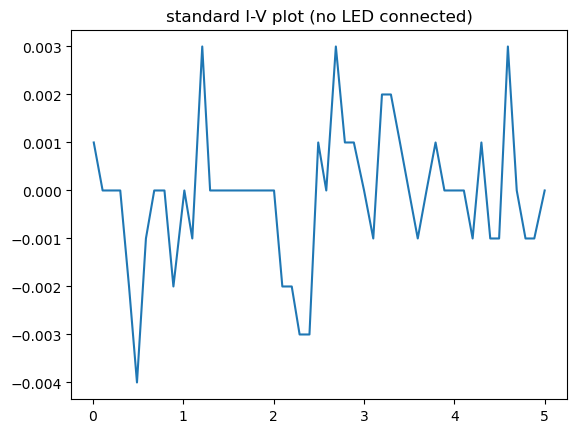

array([ 0.001,  0.   ,  0.   , -0.   , -0.002, -0.004, -0.001,  0.   ,
        0.   , -0.002, -0.   , -0.001,  0.003,  0.   ,  0.   ,  0.   ,
        0.   ,  0.   ,  0.   ,  0.   ,  0.   , -0.002, -0.002, -0.003,
       -0.003,  0.001, -0.   ,  0.003,  0.001,  0.001,  0.   , -0.001,
        0.002,  0.002,  0.001, -0.   , -0.001,  0.   ,  0.001,  0.   ,
       -0.   ,  0.   , -0.001,  0.001, -0.001, -0.001,  0.003, -0.   ,
       -0.001, -0.001,  0.   ])

In [32]:
plt.plot(np.array(standard_voltages),np.array(standard_currents))
plt.title('standard I-V plot (no LED connected)')
plt.show()
np.array(standard_currents)

# 3. I-V Characteristic - Resistor
We have saved the raw data into .csv files for the ease of data handling, though separate (and less pretty) I-V figures are also shown. We have repeated the reading for 5 times to reduce the random error for every set.

In [33]:
#resistor

import time

# Lists to store data
resistor_voltages = []
resistor_currents = []

# ---- Set ADC averaging to P16 (once) ----
ser.write(b'<P200>')
ser.readline().decode()
# ----------------------------------------

# Define sweep parameters
v_start = 0.0
v_stop = 5.0
v_step = 0.1

v = v_start
while v <= v_stop:
    # 1. Set voltage
    cmd = f'<S{v:.2f}>'
    ser.write(cmd.encode())
    ser.readline()  # read acknowledgement

    # 2. Allow voltage to stabilise
    time.sleep(0.1)

    # 3. Read LED voltage (A1)
    ser.write(b'<V2>')
    v_led = ser.readline().decode().strip()
    V = float(v_led.split()[1])

    # 4. Read current
    ser.write(b'<I1>')
    i_led = ser.readline().decode().strip()
    I = float(i_led.split()[1])

    # 5. Store data
    resistor_voltages.append(V)
    resistor_currents.append(I)

    v += v_step

In [53]:
import time, csv
import numpy as np
import matplotlib.pyplot as plt

def run_resistor_iv_sweep(
    ser,
    v_start=0.0,
    v_stop=5.0,
    v_step=0.1,
    delay=0.1
):
    """
    Run repeated I–V sweeps for a standard resistor (with styled plot + fit + R and R^2).
    """

    repeats = int(input("Enter number of repeats: "))

    for run in range(1, repeats + 1):

        ready = input(f"Repeat {run}: Ready to start? (y/n): ").strip().lower()
        if ready != "y":
            print("Measurement aborted.")
            break

        resistor_voltages = []
        resistor_currents = []

        v = v_start
        while v <= v_stop + 1e-12:
            ser.write(f'<S{v:.2f}>'.encode())
            ser.readline()

            time.sleep(delay)

            ser.write(b'<V2>')
            V_meas = float(ser.readline().decode().split()[1])

            ser.write(b'<I1>')
            I_meas = float(ser.readline().decode().split()[1])

            resistor_voltages.append(V_meas)
            resistor_currents.append(I_meas)

            v += v_step

        # Convert to arrays
        V = np.array(resistor_voltages)
        I = np.array(resistor_currents)

        # Linear fit: I = mV + c
        m, c = np.polyfit(V, I, 1)
        I_fit = m * V + c

        # Resistance + R^2
        R = 1000 / m
        ss_res = np.sum((I - I_fit)**2)
        ss_tot = np.sum((I - np.mean(I))**2)
        R2 = 1 - ss_res / ss_tot

        # ---- Plot styling ----
        plt.figure(figsize=(8, 6))
        ax = plt.gca()
        for spine in ax.spines.values():
            spine.set_linewidth(1.8)

        data_color = '0.25'       # dark grey
        fit_color = 'royalblue'   # clean contrast

        plt.scatter(V, I, s=28, color=data_color, label='Resistor data')
        plt.plot(
            V, I_fit, linewidth=2.2, color=fit_color,
            label=f'Linear fit: R ≈ {R:.2f} Ω, $R^2$ = {R2:.5f}'
        )

        plt.xlabel('Voltage / V', fontsize=22, fontweight='bold')
        plt.ylabel('Current / mA', fontsize=22, fontweight='bold')
        plt.title(f'I–V plot (resistor) — run {run}', fontsize=20, fontweight='bold')

        plt.xticks(fontsize=14, fontweight='bold')
        plt.yticks(fontsize=14, fontweight='bold')

        leg = plt.legend(
            prop={'size': 11, 'weight': 'bold'},
            loc='upper left', frameon=True, fancybox=True
        )
        frame = leg.get_frame()
        frame.set_facecolor('white')
        frame.set_edgecolor('black')
        frame.set_linewidth(1.2)
        frame.set_alpha(0.85)

        plt.tight_layout()
    
         # --------- SAVE FIGURE (NEW) ---------
        fig_name = f"resistor_IV_run{run}.png"
        plt.savefig(fig_name, dpi=600)
        # ------------------------------------
        
        plt.show()
        # Save CSV
        filename = f"resistor_IV_run{run}.csv"
        with open(filename, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(["Voltage (V)", "Current (mA)"])
            writer.writerows(zip(resistor_voltages, resistor_currents))

        print(f"Data successfully saved to {filename}\n")

Enter number of repeats:  5
Repeat 1: Ready to start? (y/n):  y


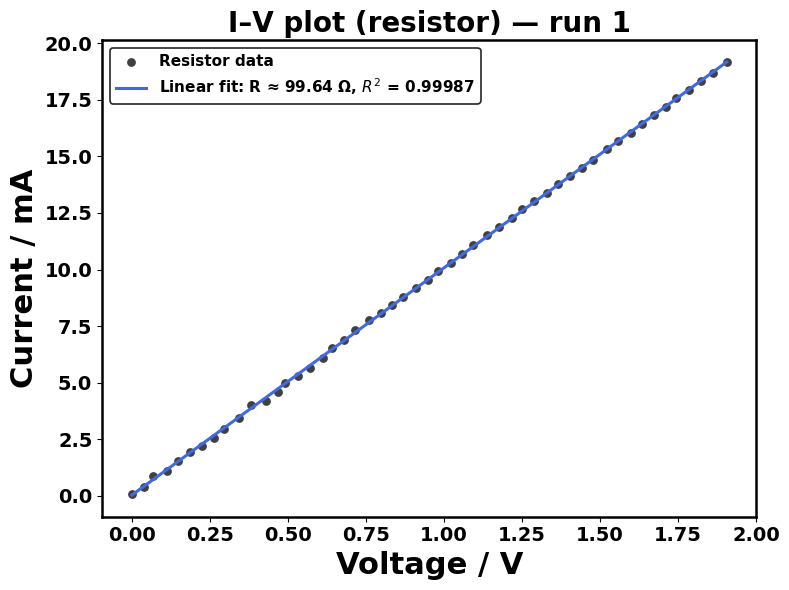

Data successfully saved to resistor_IV_run1.csv



Repeat 2: Ready to start? (y/n):  y


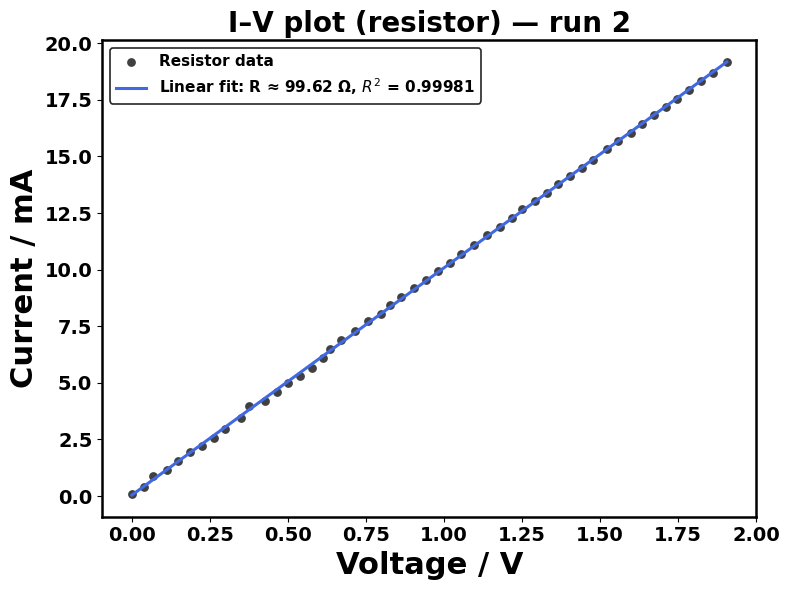

Data successfully saved to resistor_IV_run2.csv



Repeat 3: Ready to start? (y/n):  y


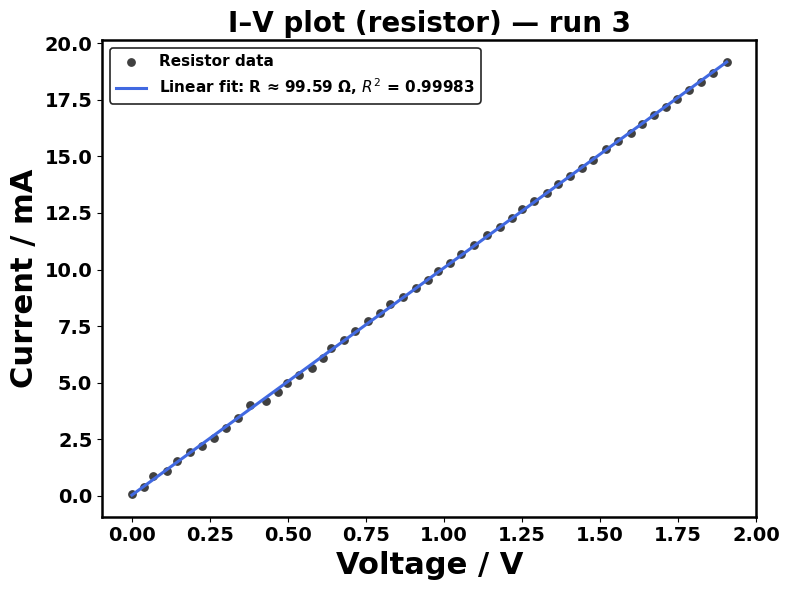

Data successfully saved to resistor_IV_run3.csv



Repeat 4: Ready to start? (y/n):  y


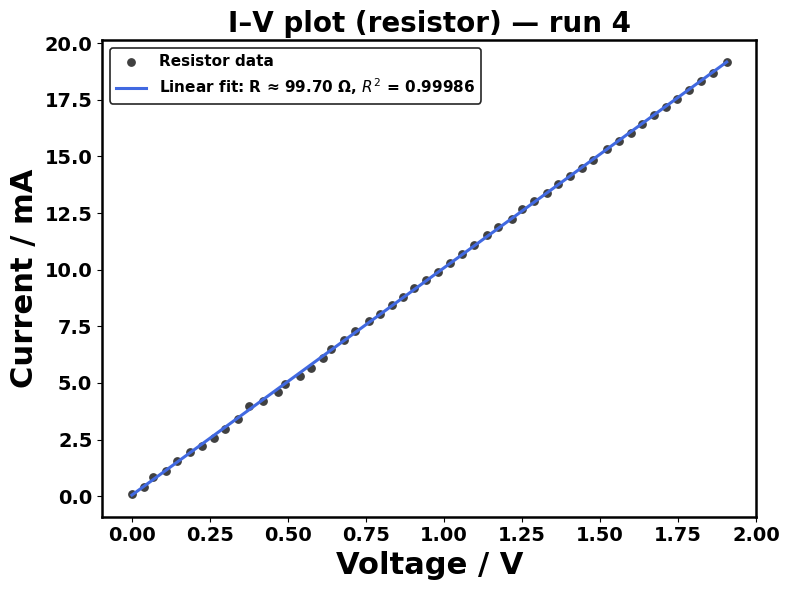

Data successfully saved to resistor_IV_run4.csv



Repeat 5: Ready to start? (y/n):  y


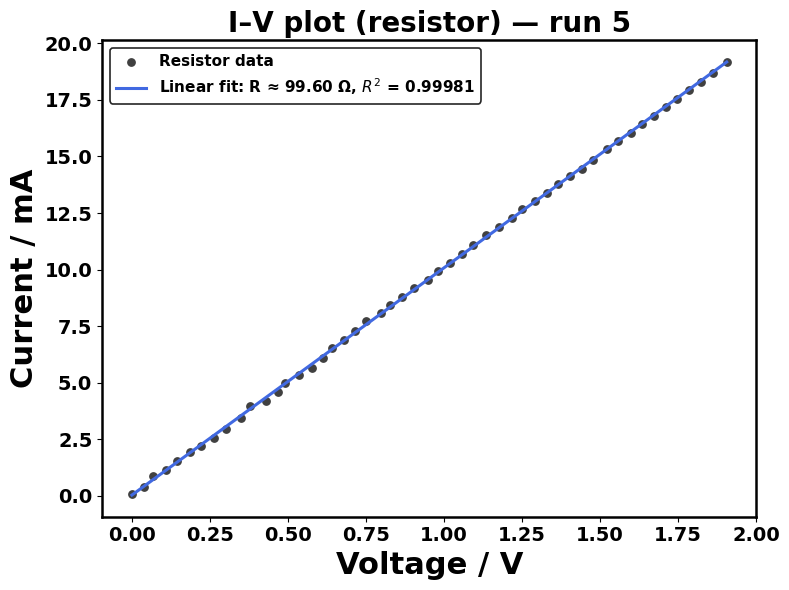

Data successfully saved to resistor_IV_run5.csv



In [54]:
run_resistor_iv_sweep(ser)

# 4. I-V Characteristic - Yellow LED
We have saved the raw data into .csv files for the ease of data handling, though separate (and less pretty) I-V figures are also shown. We have repeated the reading for 5 times to reduce the random error for every set.

In [67]:
import time, csv
import numpy as np
import matplotlib.pyplot as plt

def save_iv_csv(filename, V, I):
    """Save (V, I) arrays to CSV."""
    with open(filename, mode='w', newline='') as f:
        w = csv.writer(f)
        w.writerow(["Voltage (V)", "Current (mA)"])
        w.writerows(zip(V, I))
    print(f"Saved: {filename}")


def run_led_iv_sweep_repeats(
    ser,
    V_split,
    color_name,              
    repeats=5,                
    v_start=0.0,
    v_stop=5.0,
    v_step=0.1,
    delay=0.1,
    Pn=200,
    save_csv=True,
    save_fig=True,
    prompt_each_run=True,     
):
    """
    Run repeated LED I–V sweeps.
    For each run:
      - acquire V, I
      - fit low/high regions
      - compute R_high and R^2 (high region)
      - plot
      - optionally save CSV + PNG with run index

    Filenames:
      {color_name}_IV_run1.csv / .png
      ...
    """

    results = []  # store per-run outputs

    # Set ADC averaging once
    ser.write(f'<P{Pn}>'.encode())
    ser.readline()

    for run in range(1, repeats + 1):

        if prompt_each_run:
            ready = input(f"{color_name} run {run}/{repeats}: Ready? (y/n): ").strip().lower()
            if ready != "y":
                print("Measurement aborted.")
                break

        # ---- Acquire data ----
        voltages, currents = [], []
        v_set = v_start
        while v_set <= v_stop + 1e-12:
            ser.write(f'<S{v_set:.2f}>'.encode())
            ser.readline()
            time.sleep(delay)

            ser.write(b'<V2>')
            v_parts = ser.readline().decode(errors='replace').strip().split()
            if len(v_parts) < 2:
                raise RuntimeError(f"Bad <V2> reply: {v_parts}")
            V_meas = float(v_parts[1])

            ser.write(b'<I1>')
            i_parts = ser.readline().decode(errors='replace').strip().split()
            if len(i_parts) < 2:
                raise RuntimeError(f"Bad <I1> reply: {i_parts}")
            I_meas = float(i_parts[1])

            voltages.append(V_meas)
            currents.append(I_meas)
            v_set += v_step

        V = np.array(voltages)
        I = np.array(currents)

        # ---- Split regions ----
        low = V < V_split
        high = V > V_split

        if low.sum() < 2 or high.sum() < 2:
            raise ValueError(
                f"{color_name} run {run}: not enough points for fitting. "
                f"Below split: {low.sum()}, above split: {high.sum()}."
            )

        # ---- Fits ----
        m_low, c_low = np.polyfit(V[low], I[low], 1)
        m_high, c_high = np.polyfit(V[high], I[high], 1)

        # Current is in mA -> keep your convention:
        R_high = 1000 / m_high

        # ---- R^2 for high region only ----
        I_high_fit = m_high * V[high] + c_high
        ss_res_high = np.sum((I[high] - I_high_fit) ** 2)
        ss_tot_high = np.sum((I[high] - np.mean(I[high])) ** 2)
        R2_high = 1 - ss_res_high / ss_tot_high

        # ---- Plot ----
        V_fit_low = np.linspace(V[low].min(), V[low].max(), 100)
        V_fit_high = np.linspace(V[high].min(), V[high].max(), 100)

        plt.figure(figsize=(8, 6))
        ax = plt.gca()
        for spine in ax.spines.values():
            spine.set_linewidth(1.8)

        plt.plot(V, I, 'o', label='Data')
        plt.plot(V_fit_low, m_low * V_fit_low + c_low, '--',
                 label=f'Fit: V < {V_split}', linewidth=2.5)
        plt.plot(V_fit_high, m_high * V_fit_high + c_high, '--',
                 label=f'Fit: V > {V_split}', linewidth=2.5)
        plt.axvline(V_split, linestyle=':', color='grey', linewidth=2.5, label='Split')

        plt.text(
            0.02, 0.5,
            f"{color_name.capitalize()} run {run}/{repeats}\n"
            f"Above {V_split:.2f} V:\n"
            f"slope = {m_high:.3f} mA/V\n"
            f"R ≈ {R_high:.3f} Ω\n"
            f"$R^2$ = {R2_high:.4f}",
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

        plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
        plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
        plt.xticks(fontsize=14, fontweight='bold')
        plt.yticks(fontsize=14, fontweight='bold')
        plt.title(f'{color_name.capitalize()} LED I–V characteristic', fontsize=20, fontweight="bold")

        leg = plt.legend(
            prop={'size': 12, 'weight': 'bold'},
            loc='upper left',
            frameon=True,
            fancybox=True
        )
        frame = leg.get_frame()
        frame.set_facecolor('white')
        frame.set_edgecolor('black')
        frame.set_linewidth(1.2)
        frame.set_alpha(0.85)

        plt.tight_layout()

        # ---- Save figure ----
        if save_fig:
            fig_name = f"{color_name}_IV_run{run}.png"
            plt.savefig(fig_name, dpi=600)
            print(f"Saved figure: {fig_name}")

        plt.show()

        # ---- Save CSV ----
        if save_csv:
            csv_name = f"{color_name}_IV_run{run}.csv"
            save_iv_csv(csv_name, V, I)

        results.append({
            "run": run,
            "V": V,
            "I": I,
            "R_high": R_high,
            "R2_high": R2_high,
            "m_low": m_low, "c_low": c_low,
            "m_high": m_high, "c_high": c_high,
        })

    return results

yellow run 1/5: Ready? (y/n):  y


Saved figure: yellow_IV_run1.png


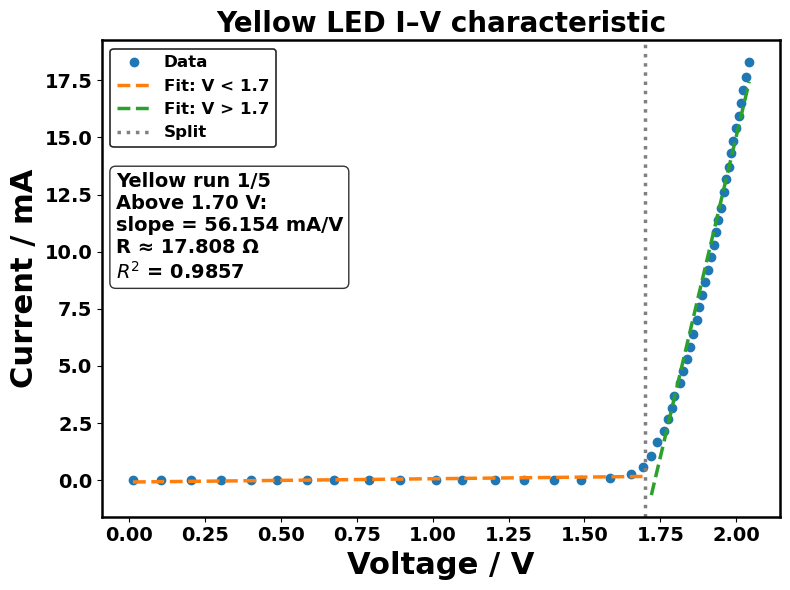

Saved: yellow_IV_run1.csv


yellow run 2/5: Ready? (y/n):  y


Saved figure: yellow_IV_run2.png


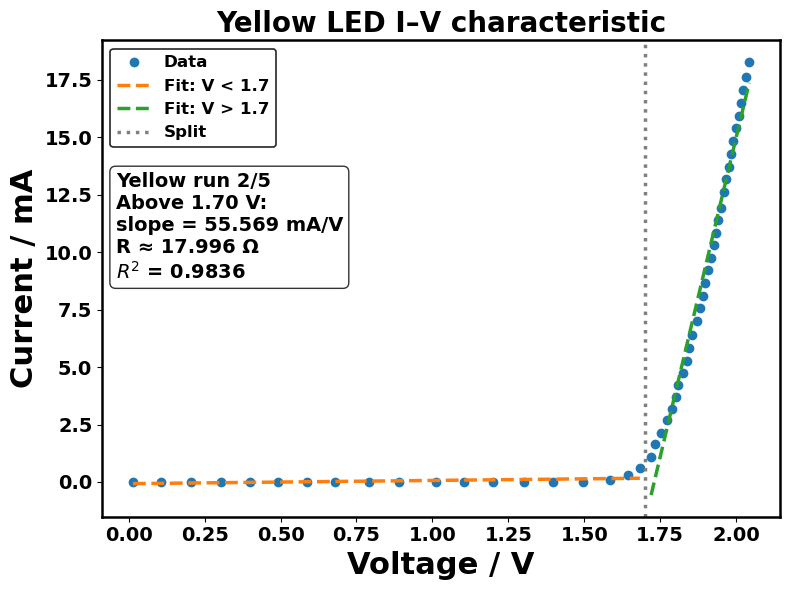

Saved: yellow_IV_run2.csv


yellow run 3/5: Ready? (y/n):  y


Saved figure: yellow_IV_run3.png


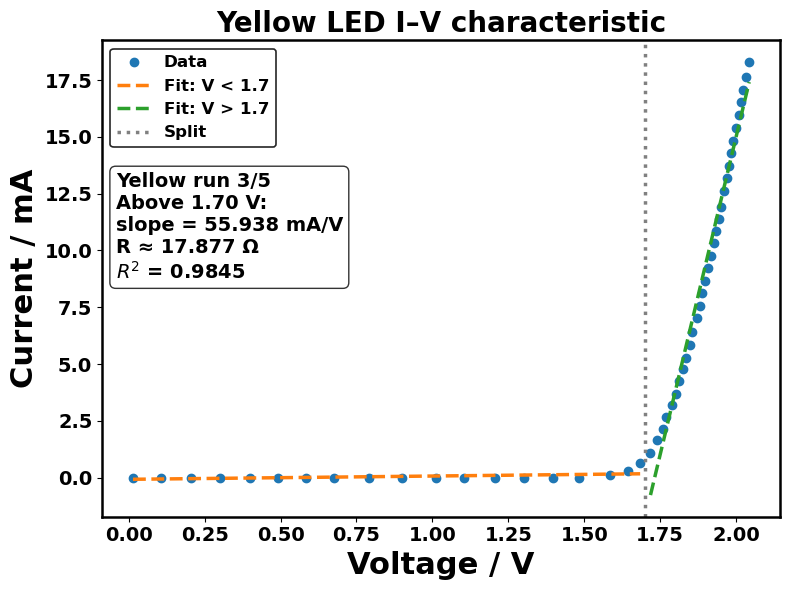

Saved: yellow_IV_run3.csv


yellow run 4/5: Ready? (y/n):  y


Saved figure: yellow_IV_run4.png


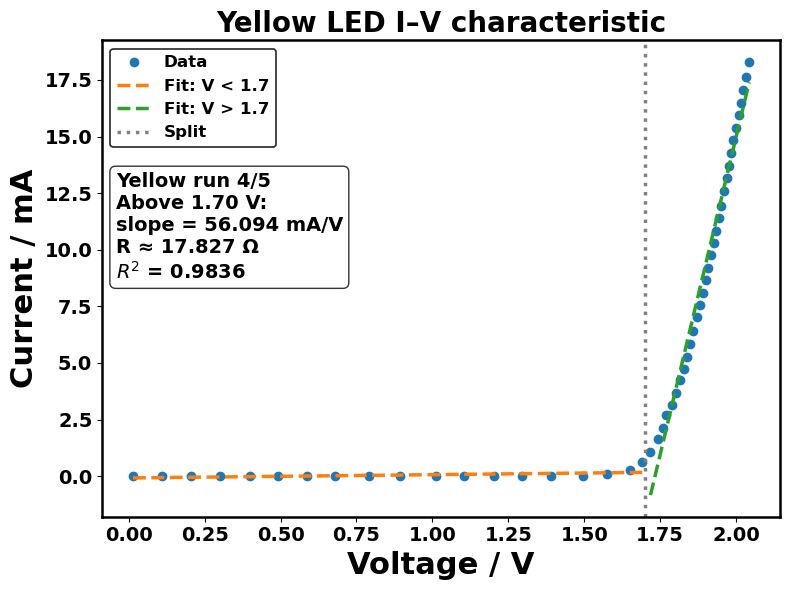

Saved: yellow_IV_run4.csv


yellow run 5/5: Ready? (y/n):  y


Saved figure: yellow_IV_run5.png


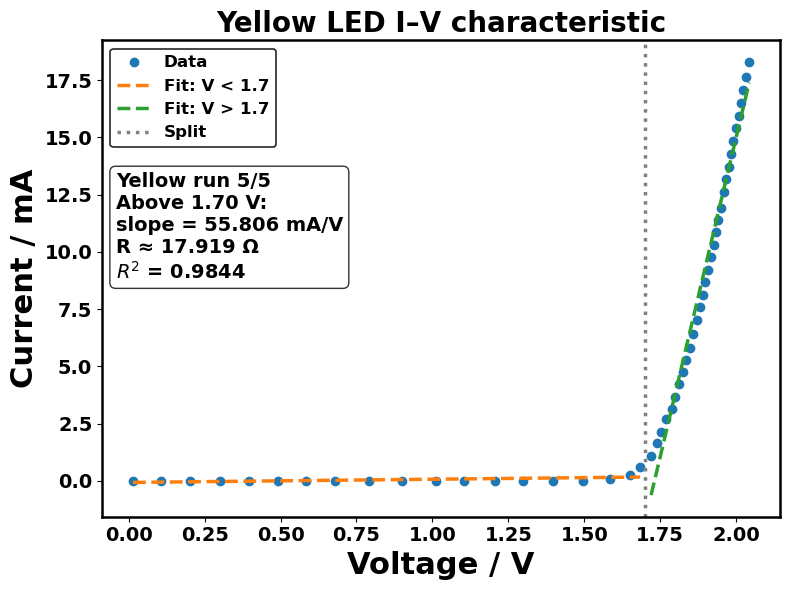

Saved: yellow_IV_run5.csv


In [68]:
results_yellow = run_led_iv_sweep_repeats(
    ser,
    V_split=1.7,
    color_name="yellow",
    repeats=5
)

# 5. I-V Characteristic - Red LED
We have saved the raw data into .csv files for the ease of data handling, though separate (and less pretty) I-V figures are also shown. We have repeated the reading for 5 times to reduce the random error for every set.

The order of LEDs for test were determined by a random process.

red run 1/5: Ready? (y/n):  y


Saved figure: red_IV_run1.png


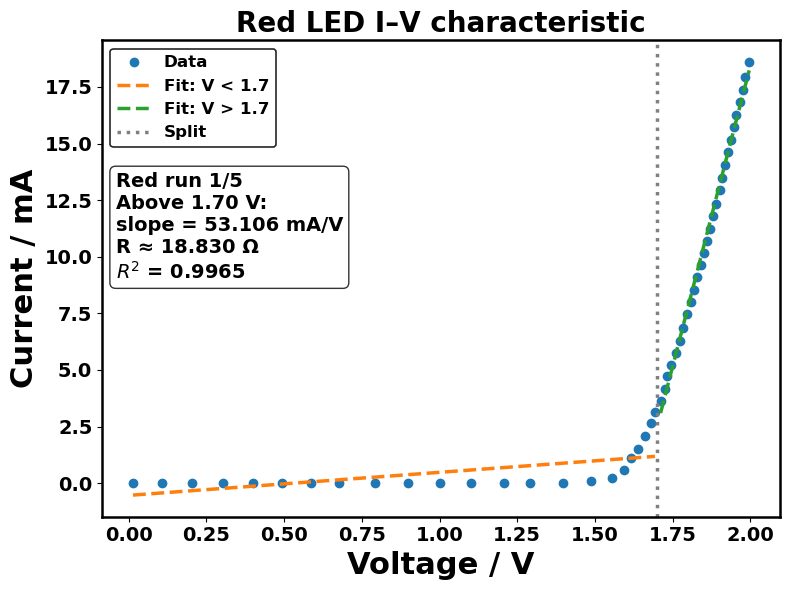

Saved: red_IV_run1.csv


red run 2/5: Ready? (y/n):  y


Saved figure: red_IV_run2.png


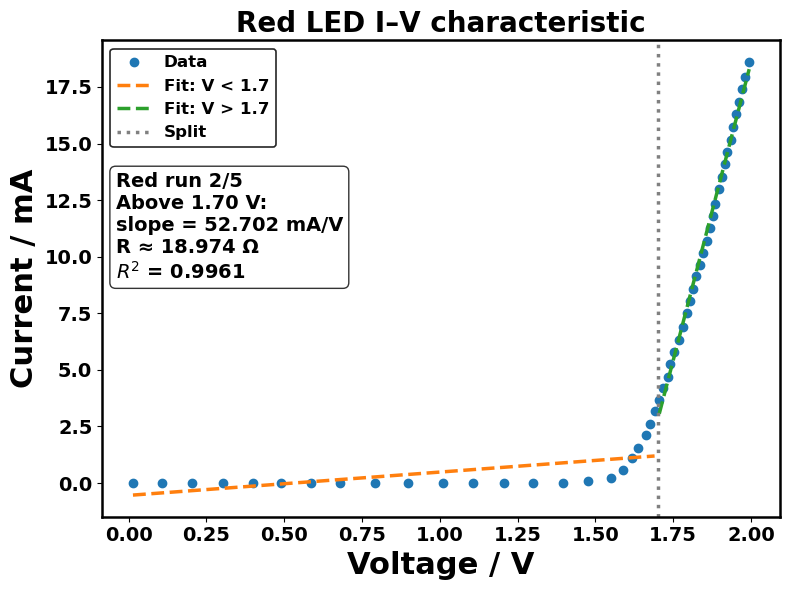

Saved: red_IV_run2.csv


red run 3/5: Ready? (y/n):  y


Saved figure: red_IV_run3.png


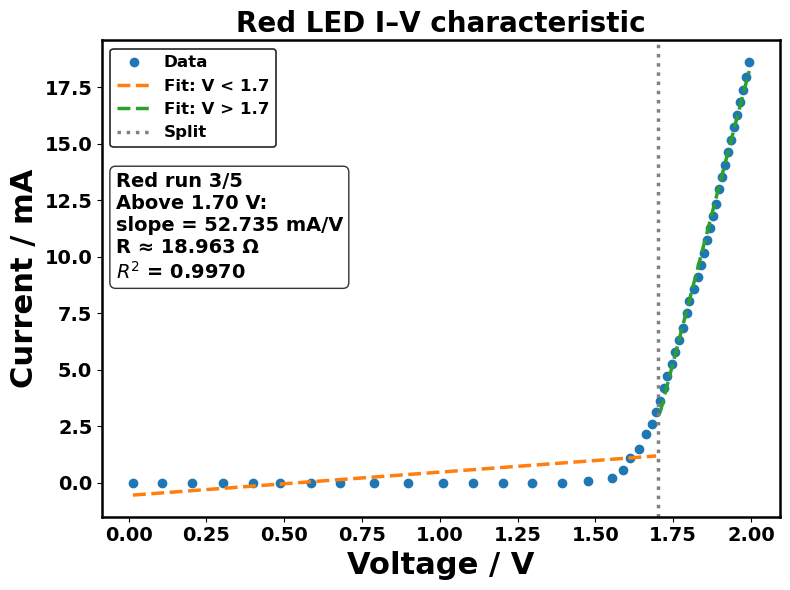

Saved: red_IV_run3.csv


red run 4/5: Ready? (y/n):  y


Saved figure: red_IV_run4.png


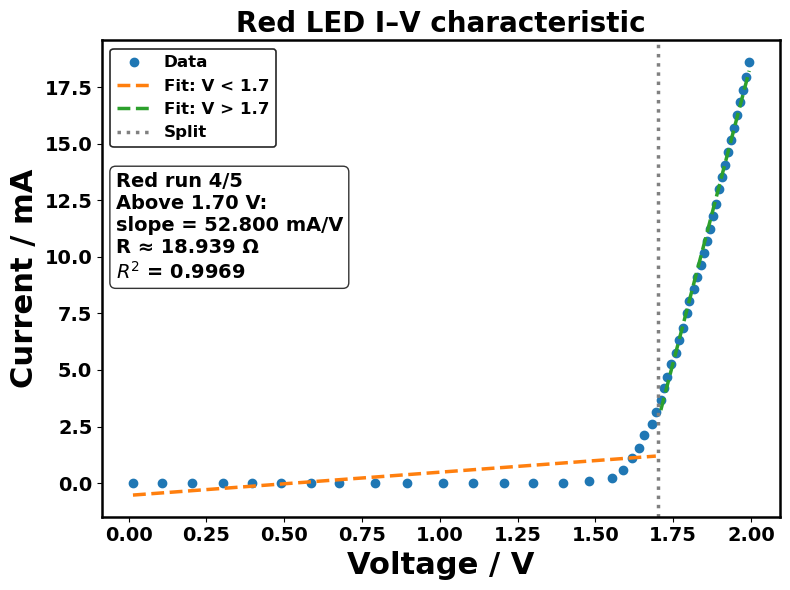

Saved: red_IV_run4.csv


red run 5/5: Ready? (y/n):  y


Saved figure: red_IV_run5.png


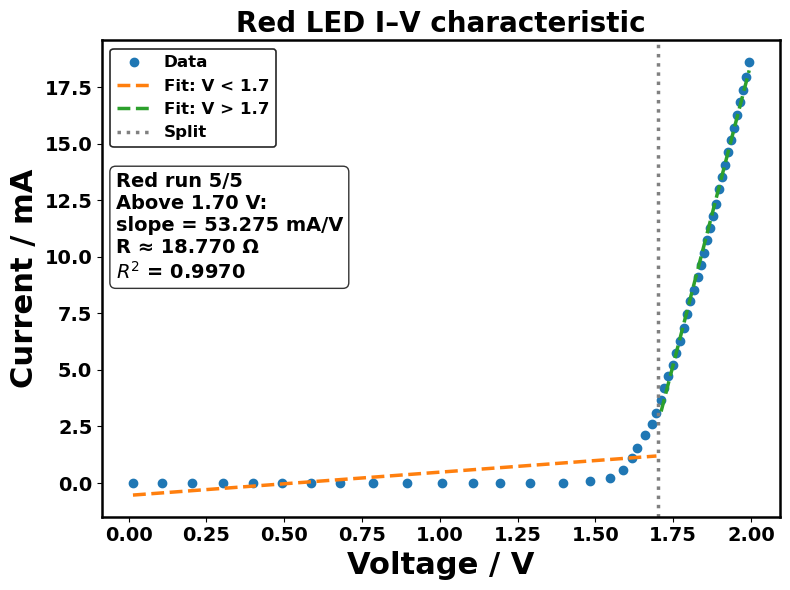

Saved: red_IV_run5.csv


In [69]:
results_yellow = run_led_iv_sweep_repeats(
    ser,
    V_split=1.7,
    color_name="red",
    repeats=5
)

# 6. I-V Characteristic - Green LED
We have saved the raw data into .csv files for the ease of data handling, though separate (and less pretty) I-V figures are also shown. We have repeated the reading for 5 times to reduce the random error for every set.

green run 1/5: Ready? (y/n):  y


Saved figure: green_IV_run1.png


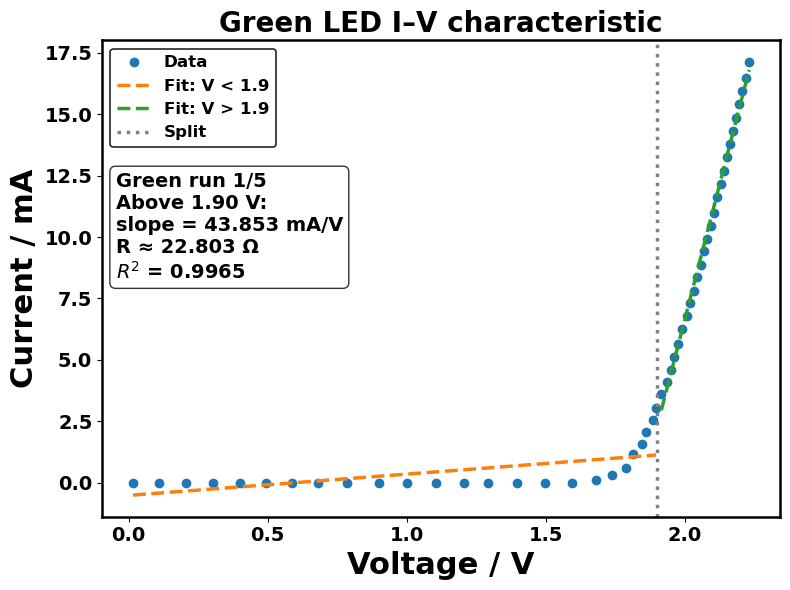

Saved: green_IV_run1.csv


green run 2/5: Ready? (y/n):  y


Saved figure: green_IV_run2.png


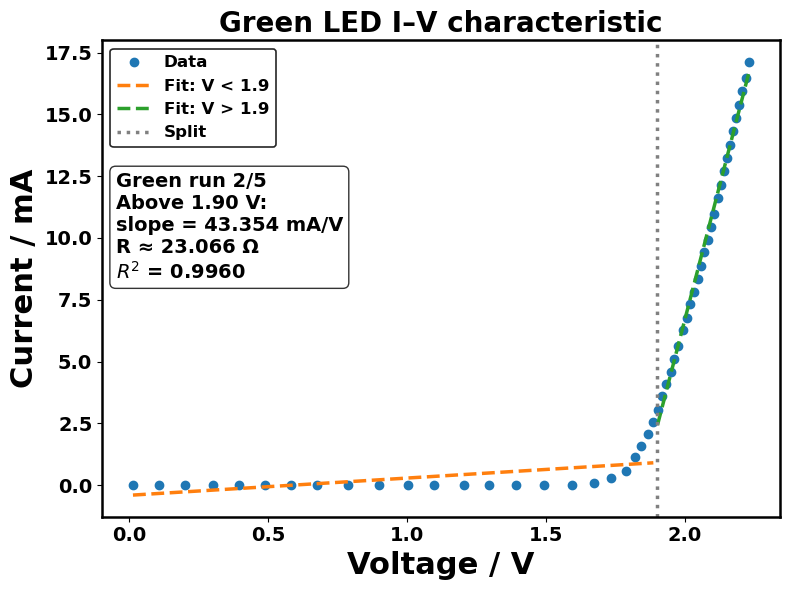

Saved: green_IV_run2.csv


green run 3/5: Ready? (y/n):  y


Saved figure: green_IV_run3.png


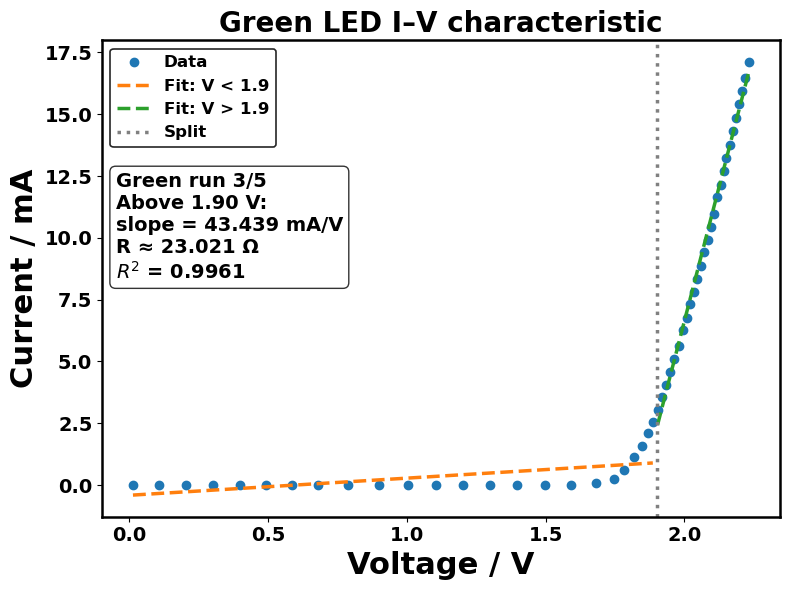

Saved: green_IV_run3.csv


green run 4/5: Ready? (y/n):  y


Saved figure: green_IV_run4.png


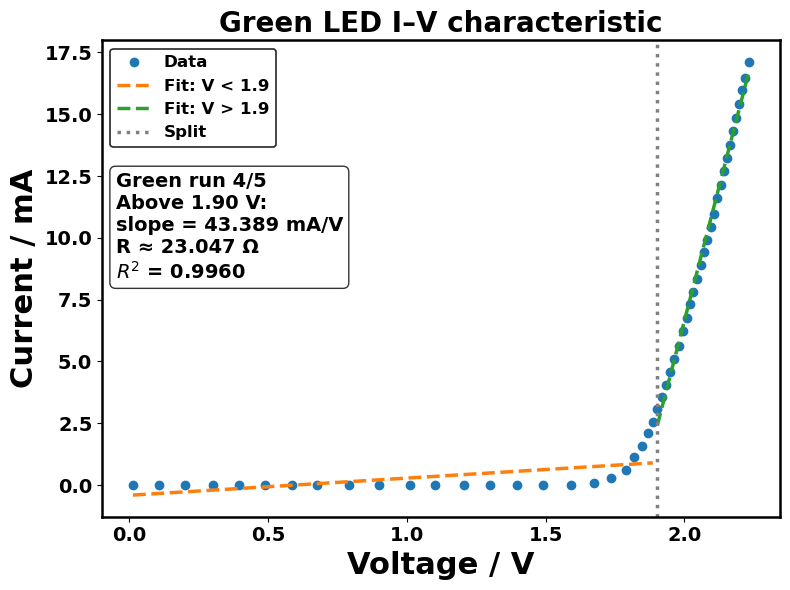

Saved: green_IV_run4.csv


green run 5/5: Ready? (y/n):  y


Saved figure: green_IV_run5.png


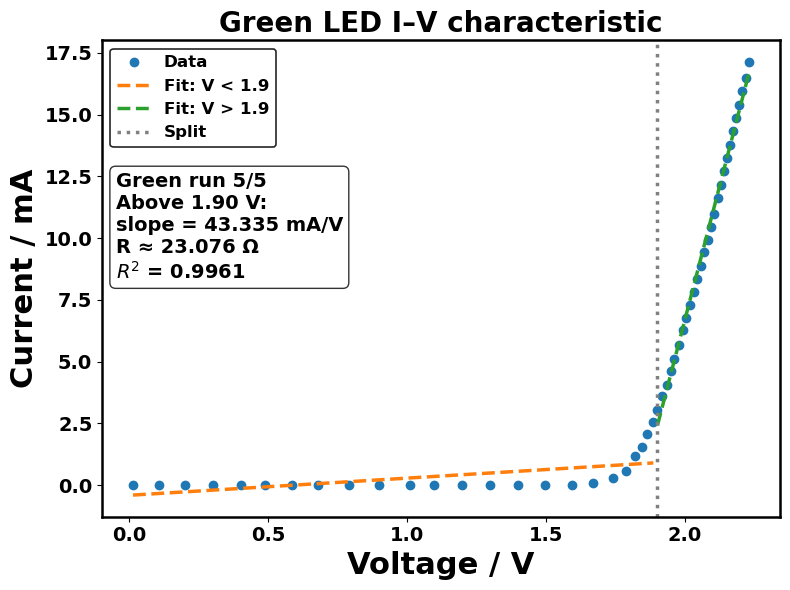

Saved: green_IV_run5.csv


In [70]:
results_yellow = run_led_iv_sweep_repeats(
    ser,
    V_split=1.9,
    color_name="green",
    repeats=5
)

# 7. I-V Characteristic - Blue LED
We have saved the raw data into .csv files for the ease of data handling, though separate (and less pretty) I-V figures are also shown. We have repeated the reading for 5 times to reduce the random error for every set.

blue run 1/5: Ready? (y/n):  y


Saved figure: blue_IV_run1.png


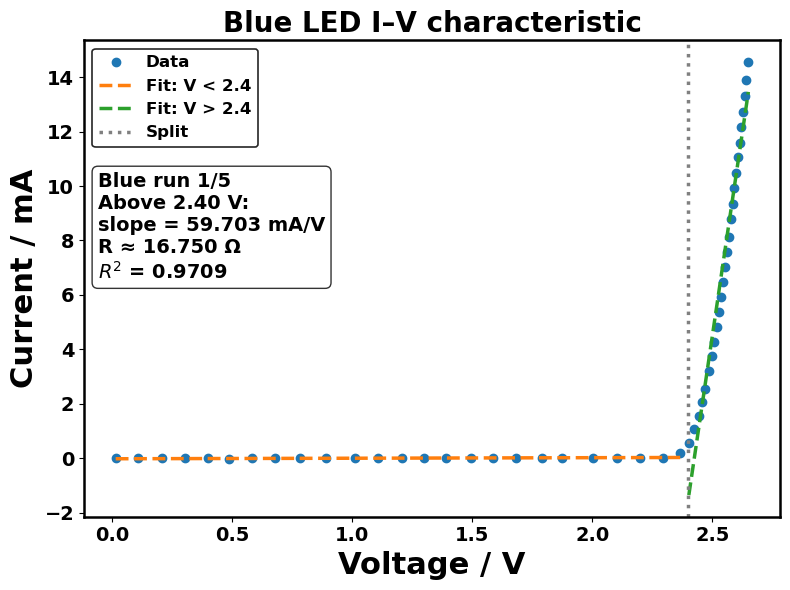

Saved: blue_IV_run1.csv


blue run 2/5: Ready? (y/n):  y


Saved figure: blue_IV_run2.png


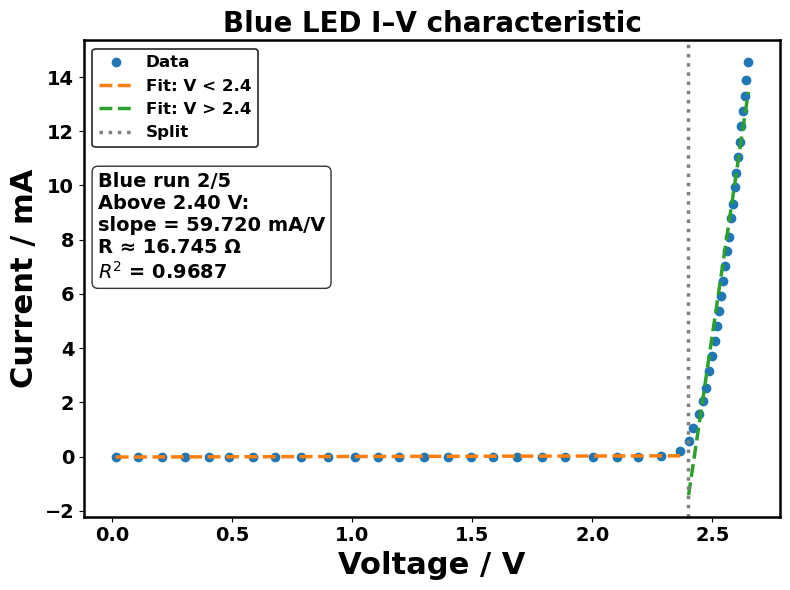

Saved: blue_IV_run2.csv


blue run 3/5: Ready? (y/n):  y


Saved figure: blue_IV_run3.png


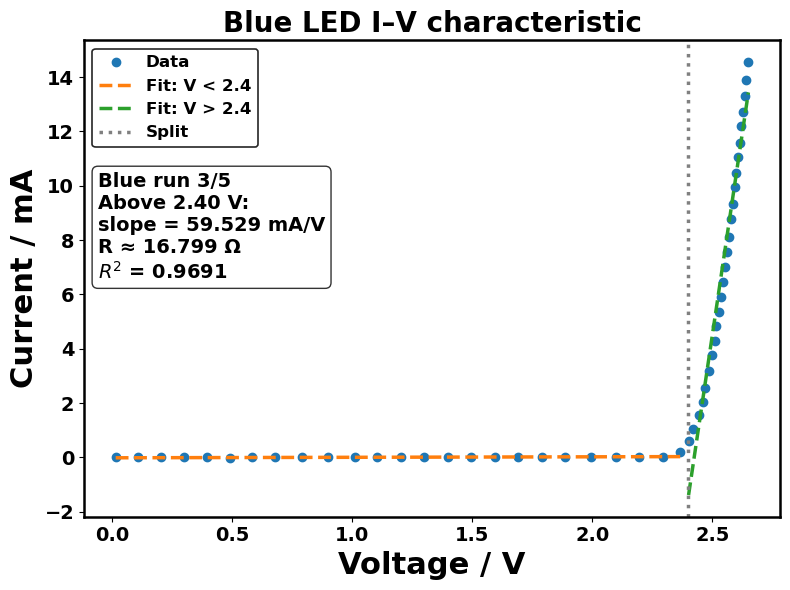

Saved: blue_IV_run3.csv


blue run 4/5: Ready? (y/n):  y


Saved figure: blue_IV_run4.png


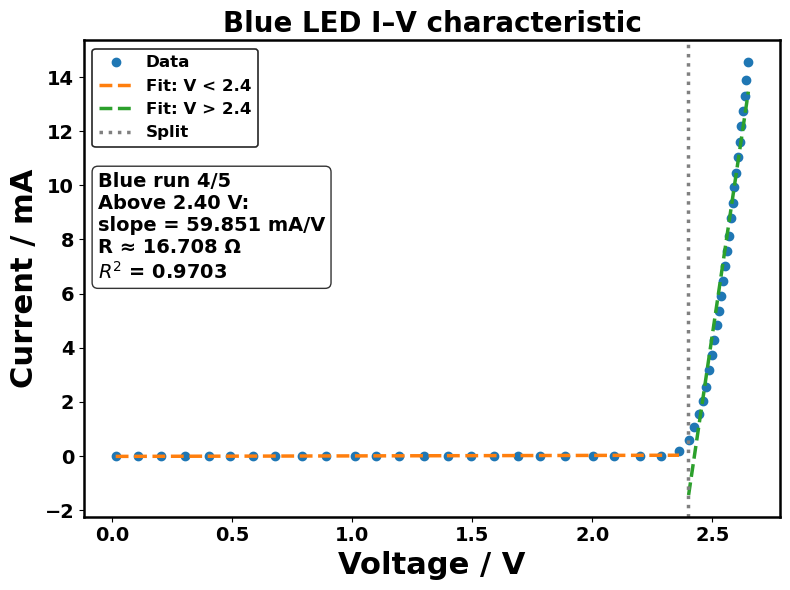

Saved: blue_IV_run4.csv


blue run 5/5: Ready? (y/n):  y


Saved figure: blue_IV_run5.png


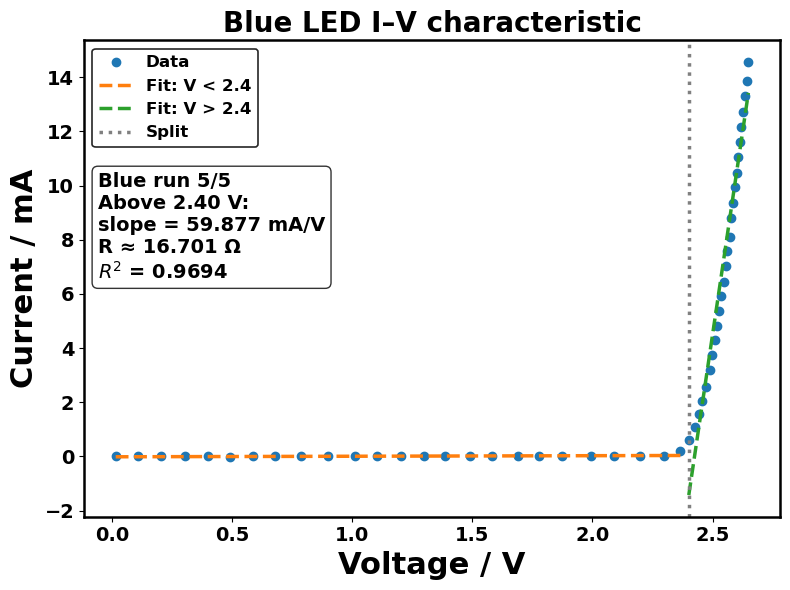

Saved: blue_IV_run5.csv


In [72]:
results_yellow = run_led_iv_sweep_repeats(
    ser,
    V_split=2.4,
    color_name="blue",
    repeats=5
)

# 8. Extension 1 - I-V Characteristic of White LED 
We got extra white LED light for extension work from Ray (who is very kind).

white run 1/5: Ready? (y/n):  y


Saved figure: white_IV_run1.png


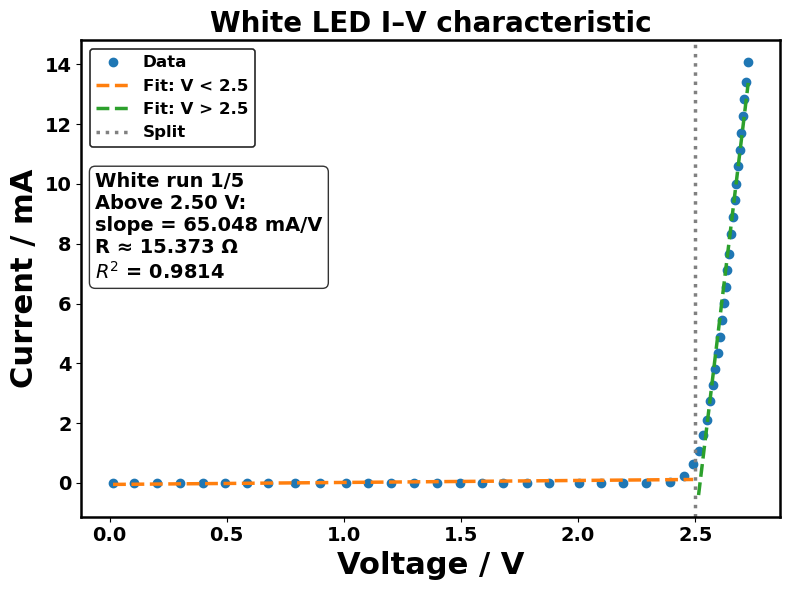

Saved: white_IV_run1.csv


white run 2/5: Ready? (y/n):  y


Saved figure: white_IV_run2.png


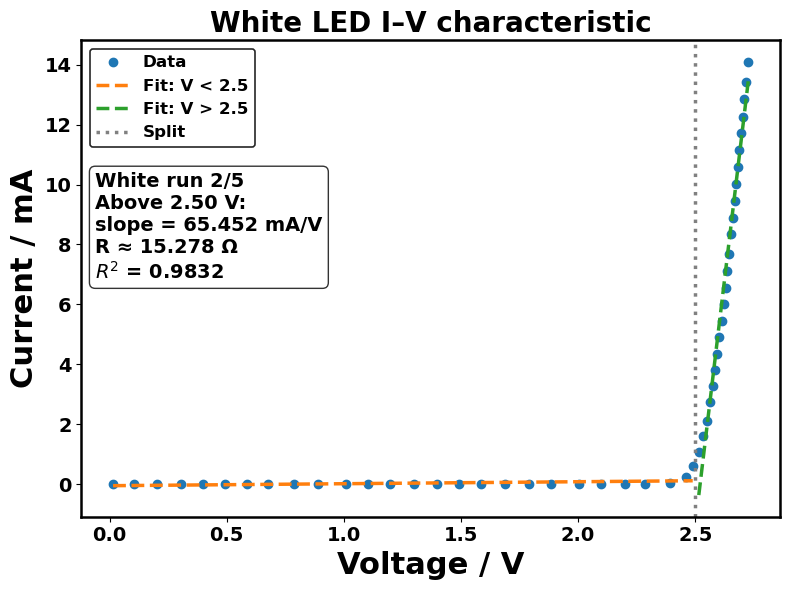

Saved: white_IV_run2.csv


white run 3/5: Ready? (y/n):  y


Saved figure: white_IV_run3.png


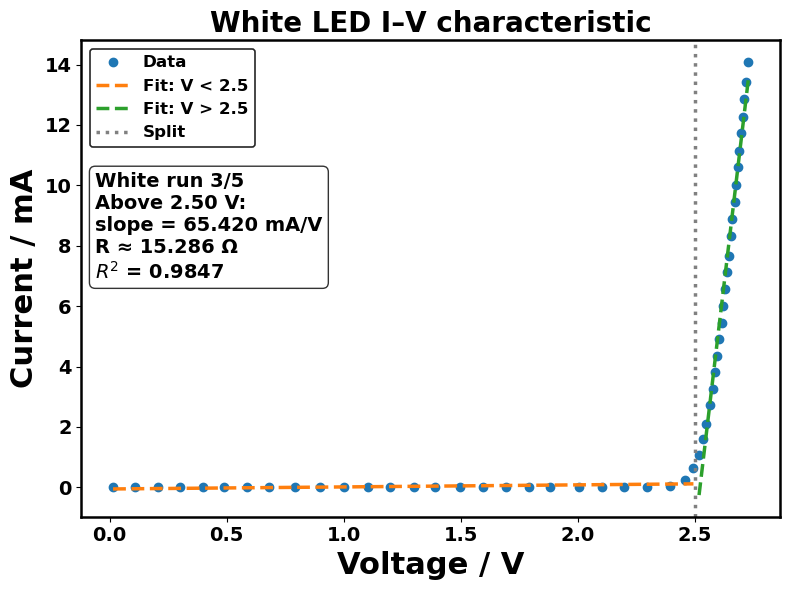

Saved: white_IV_run3.csv


white run 4/5: Ready? (y/n):  y


Saved figure: white_IV_run4.png


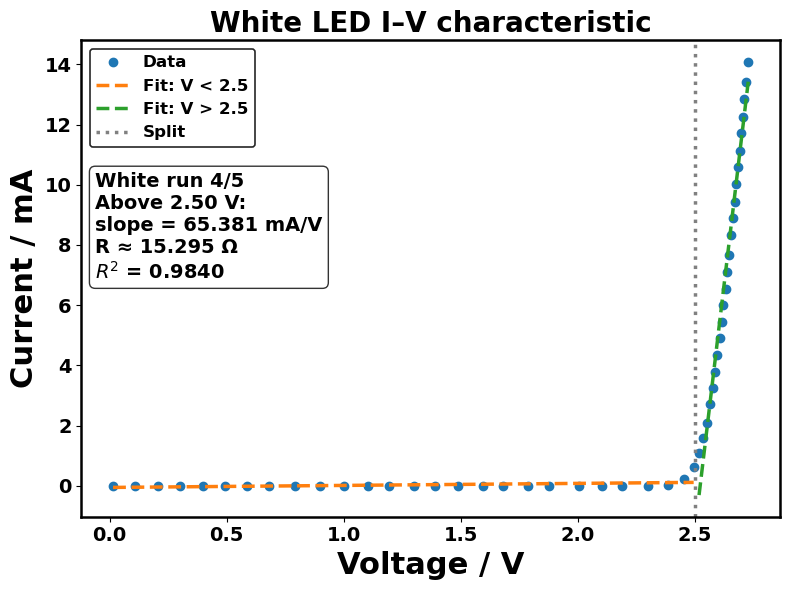

Saved: white_IV_run4.csv


white run 5/5: Ready? (y/n):  y


Saved figure: white_IV_run5.png


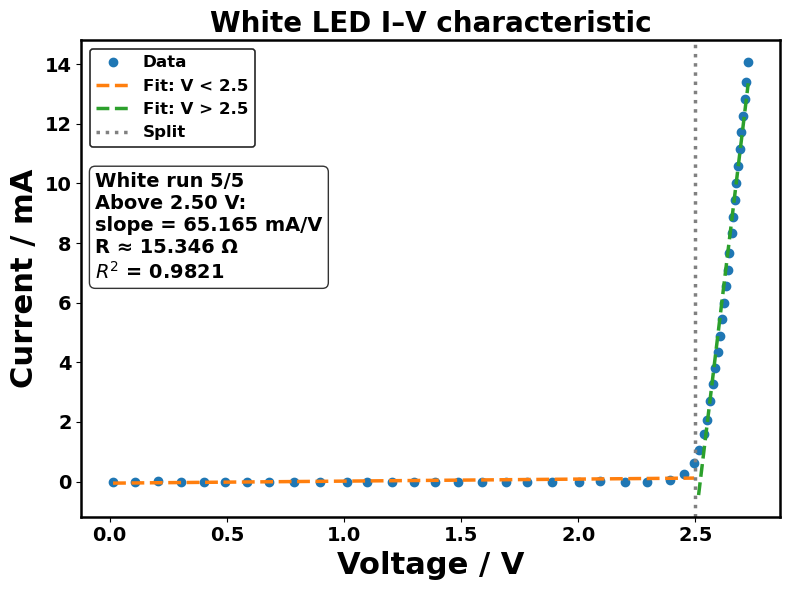

Saved: white_IV_run5.csv


In [73]:
results_yellow = run_led_iv_sweep_repeats(
    ser,
    V_split=2.5,
    color_name="white",
    repeats=5
)

# 9. Extension 2 - Liquid Nitrogen Cooling
We tried to cool the LEDs with liquid nitrogen and take readings. Wow!

In [21]:
def save_iv_csv(filename, V, I):
    """Save (V, I) arrays to CSV."""
    with open(filename, mode='w', newline='') as f:
        w = csv.writer(f)
        w.writerow(["Voltage (V)", "Current (mA)"])
        w.writerows(zip(V, I))
    print(f"Saved: {filename}")
    
def run_led_iv_sweep(
    ser,
    V_split,
    filename="led_IV.csv",
    v_start=0.0,
    v_stop=5.0,
    v_step=0.1,
    delay=0.1,
    Pn=200,
):
    """
    Sweep applied voltage, measure (V_LED, I), do 2 linear fits split by V_split,
    plot, and (optionally) save to CSV.
    Returns: V, I, (m_low, c_low), (m_high, c_high), R_high
    """

    # Set ADC averaging
    ser.write(f'<P{Pn}>'.encode())
    ser.readline()

    # Acquire data
    voltages, currents = [], []
    v_set = v_start
    while v_set <= v_stop + 1e-12:
        ser.write(f'<S{v_set:.2f}>'.encode())
        ser.readline()
        time.sleep(delay)

        ser.write(b'<V2>')
        V_meas = float(ser.readline().decode().split()[1])

        ser.write(b'<I1>')
        I_meas = float(ser.readline().decode().split()[1])

        voltages.append(V_meas)
        currents.append(I_meas)
        v_set += v_step

    V = np.array(voltages)
    I = np.array(currents)

    # Split & fit (guard against empty regions)
    low = V < V_split
    high = V > V_split

    if low.sum() < 2 or high.sum() < 2:
        raise ValueError(
            f"Not enough points for fitting. "
            f"Below split: {low.sum()}, above split: {high.sum()}. "
            f"Try a different V_split."
        )

    m_low, c_low = np.polyfit(V[low], I[low], 1)
    m_high, c_high = np.polyfit(V[high], I[high], 1)

    # I is in mA, so to compute ohm, we need to multiply by 1000.
    R_high = 1000 / m_high

    V_fit_low = np.linspace(V[low].min(), V[low].max(), 100)
    V_fit_high = np.linspace(V[high].min(), V[high].max(), 100)
    
    # Plot
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    plt.plot(V, I, 'o', label='Data')
    plt.plot(V_fit_low, m_low * V_fit_low + c_low, '--', label=f'Fit: V < {V_split}', linewidth=2.5)
    plt.plot(V_fit_high, m_high * V_fit_high + c_high, '--', label=f'Fit: V > {V_split}', linewidth=2.5)
    plt.axvline(V_split, linestyle=':', label='Split', color='grey', linewidth=2.5)

    plt.text(
        0.02, 0.6,
        f"Above {V_split:.2f} V:\n"
        f"slope = {m_high:.3f} mA/V\n"
        f"R ≈ {R_high:.3f} Ω",
        transform=plt.gca().transAxes,
        fontsize=14,
        fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
    plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
    plt.xticks(fontsize=14, fontweight='bold')
    plt.yticks(fontsize=14, fontweight='bold')
    plt.title('LED I–V characteristic', fontsize=20, fontweight="bold")
    leg = plt.legend(
    prop={'size': 12, 'weight': 'bold'},
    loc='upper left',
    frameon=True,
    fancybox=True
    )

    frame = leg.get_frame()
    frame.set_facecolor('white')
    frame.set_edgecolor('black')
    frame.set_linewidth(1.2)
    frame.set_alpha(0.85)

    plt.tight_layout()
    plt.show()

    # ---- CSV save toggle (comment/uncomment ONE line) ----
    save_iv_csv(filename, V, I)  # <--- comment this ONE line to disable saving
    # -----------------------------------------------------
    #print(f"Resistance after turn-on voltage is {R_high:.3f} Ω")
    return 

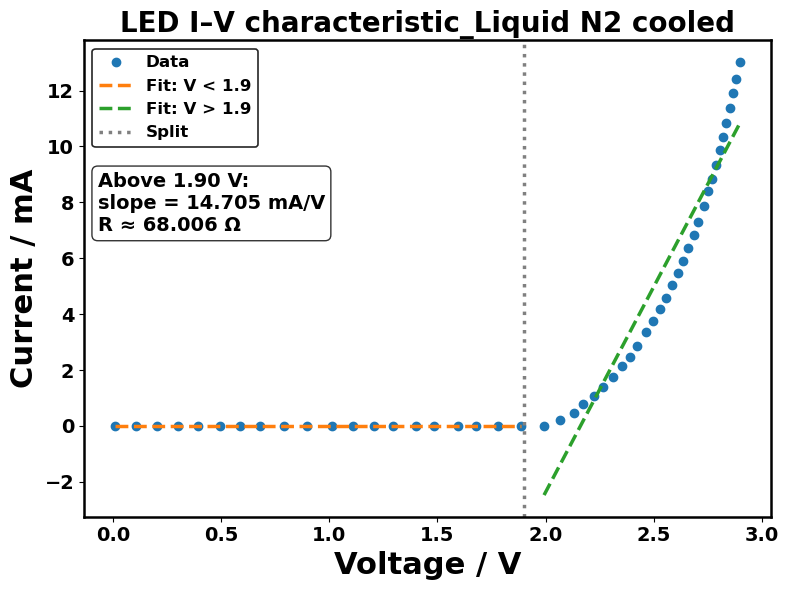

Saved: green_LiquidN2_cooled.csv


In [36]:
run_led_iv_sweep(ser, 1.9, filename="green_LiquidN2_cooled.csv")